# Feature Impact on Prediction

In this notebook, we analyse how the features selected by the final model influence its predictions.

We use SHAP (SHapley Additive exPlanations) to quantify the contribution of each selected feature to the model output.

To obtain a global feature importance, we calculate the SHAP values for all observations in the test set and then compute the mean absolute SHAP value for each feature. This allows us to assess which features have the strongest overall influence on the model's predictions.

We compare the feature contributions for:

- the final model predictions without the offset adjustment

This comparison allows us to evaluate whether the offset changes the relative importance of the selected predictive features.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import pathlib
import sys
PROJECT_ROOT = pathlib.Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.py_def_class

In [2]:
final_model = joblib.load(
    PROJECT_ROOT / "model" / "final_model" / "final_model_qualifying.joblib"
)

X_test = pd.read_csv(r"..\data\model_data\test\X_test.csv")
X_train = pd.read_csv(r"..\data\model_data\train\X_train.csv")
y_test = pd.read_csv(r"..\data\model_data\test\y_test.csv")

step_names = list(final_model.named_steps.keys())
selector_idx = step_names.index("Feature_Selector")
#everything BEFORE Feature_Selector
X_train_encoded = final_model[:selector_idx].transform(X_train)
X_test_encoded = final_model[:selector_idx].transform(X_test)
# Feature selector
selector = final_model["Feature_Selector"]

#all the selected features
X_train_selected = selector.transform(X_train_encoded)
X_test_selected = selector.transform(X_test_encoded)

print(X_test_selected.columns)

model_after_selector = final_model[selector_idx + 1:]
background = shap.sample(
    X_train_selected,
    100,
    random_state=42
)

explainer = shap.Explainer(
    model_after_selector.predict,
    background
)

shap_values = explainer(X_test_selected)

c:\Users\gandj\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gandj\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gandj\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.1 when using version 1.6.1. This might lead to 

Index(['laptime_sum_sectortimes_p1', 'laptime_sum_sectortimes_p2',
       'laptime_sum_sectortimes_p3', 'AirTemp_quali', 'Humidity_quali',
       'GP_mean', 'Compound_quali_mean'],
      dtype='object')
[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.7842059975472844 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.06590921163569698, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.06590921163569698
[LightGBM] [Warning] bagging_fraction is set=0.5906195061033961, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5906195061033961
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be igno

ExactExplainer explainer:  62%|██████▏   | 296/475 [00:10<00:03, 46.73it/s]

[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.7842059975472844 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.06590921163569698, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.06590921163569698
[LightGBM] [Warning] bagging_fraction is set=0.5906195061033961, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5906195061033961
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda

ExactExplainer explainer:  63%|██████▎   | 301/475 [00:10<00:05, 33.35it/s]

...

[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.7842059975472844 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.06590921163569698, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.06590921163569698
[LightGBM] [Warning] bagging_fraction is set=0.5906195061033961, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5906195061033961
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda

ExactExplainer explainer:  99%|█████████▉| 471/475 [00:16<00:00, 30.48it/s]

[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.7842059975472844 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.06590921163569698, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.06590921163569698
[LightGBM] [Warning] bagging_fraction is set=0.5906195061033961, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5906195061033961
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda

ExactExplainer explainer: 476it [00:16, 11.35it/s]                         


[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.7842059975472844 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.06590921163569698, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.06590921163569698
[LightGBM] [Warning] bagging_fraction is set=0.5906195061033961, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5906195061033961
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] lambda_l1 is set with reg_alpha=0.0, l1_regularization=1.7377001319324172 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda

In [3]:
global_shap = pd.DataFrame({
    "Feature": X_test_selected.columns,
    "Mean_ABS_SHAP": np.abs(shap_values.values).mean(axis=0)
})

global_shap = (
    global_shap
    .sort_values("Mean_ABS_SHAP", ascending=False)
    .reset_index(drop=True)
)
global_shap["Importance_%"] = (
    global_shap["Mean_ABS_SHAP"]
    / global_shap["Mean_ABS_SHAP"].sum()
    * 100
)
global_shap.to_csv(r"..\model\shap\feature_impact_on_pred_shap.csv",index=False)
global_shap

,Feature,Mean_ABS_SHAP,Importance_%
0,GP_mean,3.270989,29.090824
1,laptime_sum_sectortimes_p1,2.262952,20.125759
2,laptime_sum_sectortimes_p3,2.015876,17.928367
3,laptime_sum_sectortimes_p2,1.879212,16.712935
4,Compound_quali_mean,1.457028,12.958208
5,Humidity_quali,0.208577,1.854999
6,AirTemp_quali,0.149423,1.328908


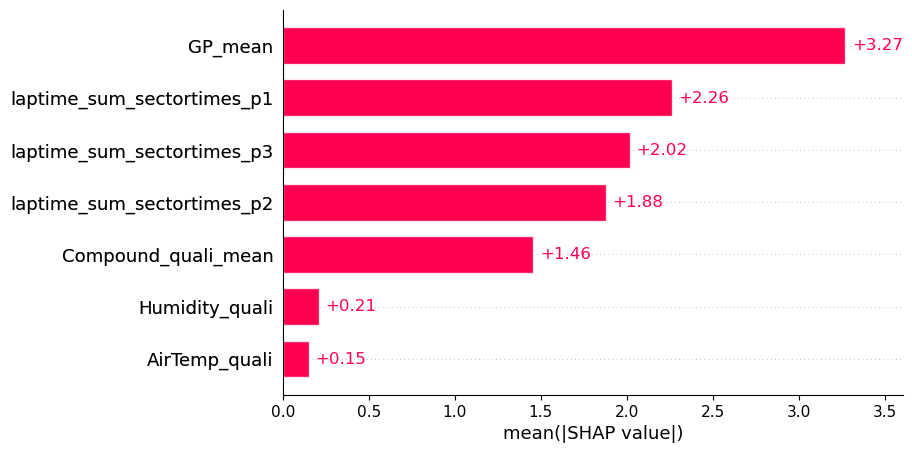

In [4]:
shap.plots.bar(shap_values)

**Global SHAP Feature Importance**

Mean absolute SHAP values are used to rank the selected features according to their overall influence on model predictions. Because absolute values are used, this analysis measures the magnitude of the impact but not its direction.

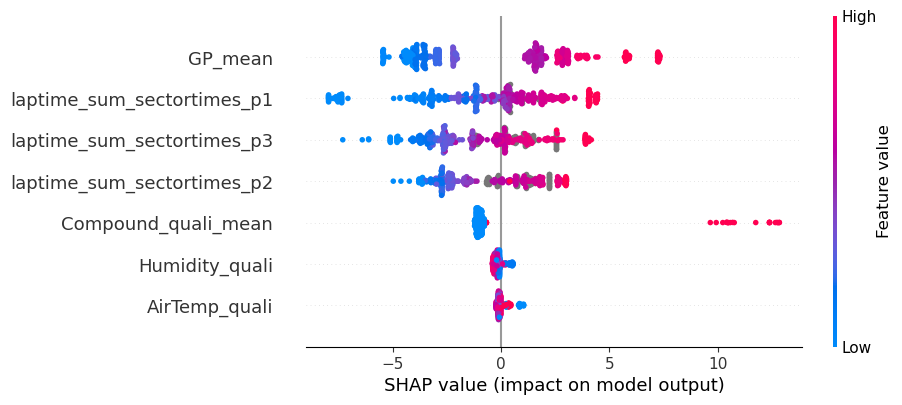

In [5]:
shap.plots.beeswarm(shap_values)

**SHAP Beeswarm Plot**

The beeswarm plot shows the distribution of SHAP values across individual test observations. It therefore provides information about both the magnitude and direction of each feature's effect on the model prediction. The color indicates whether the underlying feature value is relatively high or low.